In [1]:
import glob
import re
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
import math
import collections
import numpy as np
from scipy import signal
from scipy.fftpack import fft, fftfreq
from scipy.stats import iqr
from scipy.stats import pearsonr
from scipy.stats import skew
from scipy.stats import kurtosis
# from spectrum import *
from statsmodels.robust import mad as median_deviation

In [2]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

# データ読み込み、可視化

In [3]:
os.getcwd()
os.chdir('../')

In [4]:
dataset_dir = "/Desktop/data"

In [5]:
target_dirs = [td+'/' for td in os.listdir(os.getcwd()+dataset_dir)  if not td.startswith('.')]
target_dirs

['me1/',
 'me10/',
 'me11/',
 'me11 (10)/',
 'me11 (2)/',
 'me11 (3)/',
 'me11 (4)/',
 'me11 (5)/',
 'me11 (6)/',
 'me11 (7)/',
 'me11 (8)/',
 'me11 (9)/',
 'me2/',
 'me21/',
 'me21 (10)/',
 'me21 (2)/',
 'me21 (3)/',
 'me21 (4)/',
 'me21 (5)/',
 'me21 (6)/',
 'me21 (7)/',
 'me21 (8)/',
 'me21 (9)/',
 'me3/',
 'me31/',
 'me31 (10)/',
 'me31 (2)/',
 'me31 (3)/',
 'me31 (4)/',
 'me31 (5)/',
 'me31 (6)/',
 'me31 (7)/',
 'me31 (8)/',
 'me31 (9)/',
 'me4/',
 'me5/',
 'me6/',
 'me7/',
 'me8/',
 'me9/',
 'other1/',
 'other10/',
 'other11/',
 'other12/',
 'other13/',
 'other14/',
 'other15/',
 'other16/',
 'other17/',
 'other18/',
 'other19/',
 'other2/',
 'other20/',
 'other21/',
 'other22/',
 'other23/',
 'other24/',
 'other25/',
 'other26/',
 'other27/',
 'other28/',
 'other29/',
 'other3/',
 'other30/',
 'other4/',
 'other41/',
 'other41 (10)/',
 'other41 (2)/',
 'other41 (3)/',
 'other41 (4)/',
 'other41 (5)/',
 'other41 (6)/',
 'other41 (7)/',
 'other41 (8)/',
 'other41 (9)/',
 'other5/'

In [6]:
df_acc = pd.read_csv(os.getcwd()+ dataset_dir +"/" +target_dirs[0]+ 'Accelerometer.csv')

In [7]:
print(os.getcwd()+ dataset_dir + "/" +target_dirs[0])

C:\Users\inota/Desktop/data/me1/


In [10]:
def sliding_window(data, window, step_size):
    shape = (int(data.shape[-1] / window * window / step_size - 1), window)
    strides = (data.strides[-1] * step_size, data.strides[-1])
    return np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)


def median_filter(data, f_size=3):
    median_signal = signal.medfilt(data, f_size)
    return np.insert(median_signal, 0, median_signal[0])

def magnitude(x, y, z):
    return np.linalg.norm([x, y, z])


def graph_plot(data):
    pd.DataFrame(data).plot()


def mad(data, axis=None):
    """
    Compute *Median Absolute Deviation* of an array along given axis.
    """
    #     med = np.median(data, axis=axis, keepdims=True)
    #     mad = np.median(np.absolute(data - med), axis=axis)  # MAD along given axis
    mad_value = float(median_deviation(data))
    # print(mad_value)
    return mad_value


def calc_fft_signal(data):
    shape = data.shape
    N = shape[0]  # FFTのサンプル数
    #     hanningWindow = np.hanning(N)  # ハニング窓
    #     fqy = np.abs(fft(hanningWindow * data))

    fqy = fft(data)

    fqy = 2.0 / N * np.abs(fqy[0:N // 2])

    # return fqy[0:int(shape[0] / 2)]
    return fqy


In [11]:
time_xyz_feature_names = [
't-Mean-1',
't-Mean-2',
't-Mean-3',
't-STD-1',
't-STD-2',
't-STD-3',
't-Mad-1',
't-Mad-2',
't-Mad-3',
't-Max-1',
't-Max-2',
't-Max-3',
't-Min-1',
't-Min-2',
't-Min-3']

def time_xyz_feature_extraction(data_x, data_y, data_z):
    t_mean_x = data_x.mean()
    t_mean_y = data_y.mean()
    t_mean_z = data_z.mean()
    t_std_x = data_x.std()
    t_std_y = data_y.std()
    t_std_z = data_z.std()
    t_mad_x = mad(data_x)
    t_mad_y = mad(data_y)
    t_mad_z = mad(data_z)
    t_max_x = data_x.max()
    t_max_y = data_y.max()
    t_max_z = data_z.max()
    t_min_x = data_x.min()
    t_min_y = data_y.min()
    t_min_z = data_z.min()

    f_all = [t_mean_x, t_mean_y, t_mean_z, t_std_x, t_std_y, t_std_z, t_mad_x, t_mad_y, t_mad_z, \
             t_max_x, t_max_y, t_max_z, t_min_x, t_min_y, t_min_z]
    # print(len(f_all))

    return np.array(f_all)

### time_mag_feature_extraction

time_mag_feature_names = [
't-Mean-mag',
't-STD-mag',
't-Mad-mag',
't-Max-mag',
't-Min-mag']

def time_mag_feature_extraction(data_mag):
    t_mean_mag = data_mag.mean()
    t_std_mag = data_mag.std()
    t_mad_mag = mad(data_mag)
    t_max_mag = data_mag.max()
    t_min_mag = data_mag.min()

    t_all = [t_mean_mag, t_std_mag, t_mad_mag, t_max_mag, t_min_mag]

    return np.array(t_all)


frequency_xyz_feature_names = ['f-Mean-1',
'f-Mean-2',
'f-Mean-3',
'f-STD-1',
'f-STD-2',
'f-STD-3',
'f-Mad-1',
'f-Mad-2',
'f-Mad-3',
'f-Max-1',
'f-Max-2',
'f-Max-3',
'f-Min-1',
'f-Min-2',
'f-Min-3',
'f-Skewness-1',
'f-Skewness-2',
'f-Skewness-3',
'f-Kurtosis-1',
'f-Kurtosis-2',
'f-Kurtosis-3']

def frequency_xyz_feature_extraction(data_x, data_y, data_z, fs=50.0):
    df_freqList = pd.DataFrame(fftfreq(int(2 * len(data_x)), d=1.0 / fs)[0:len(data_x)])

    f_mean_x = data_x.mean()
    f_mean_y = data_y.mean()
    f_mean_z = data_z.mean()
    f_std_x = data_x.std()
    f_std_y = data_y.std()
    f_std_z = data_z.std()
    f_mad_x = mad(data_x)
    f_mad_y = mad(data_y)
    f_mad_z = mad(data_z)
    f_max_x = data_x.max()
    f_max_y = data_y.max()
    f_max_z = data_z.max()
    f_min_x = data_x.min()
    f_min_y = data_y.min()
    f_min_z = data_z.min()
    f_skewness_x = skew(data_x)
    f_skewness_y = skew(data_y)
    f_skewness_z = skew(data_z)
    f_kurtosis_x = kurtosis(data_x)
    f_kurtosis_y = kurtosis(data_y)
    f_kurtosis_z = kurtosis(data_z)


    f_all = [f_mean_x, f_mean_y, f_mean_z, f_std_x, f_std_y, f_std_z, f_mad_x, f_mad_y, f_mad_z, \
             f_max_x, f_max_y, f_max_z, f_min_x, f_min_y, f_min_z, f_skewness_x, f_skewness_y, f_skewness_z, \
             f_kurtosis_x, f_kurtosis_y, f_kurtosis_z]

    return np.array(f_all)

### frequency_mag_feature_extraction
frequency_mag_feature_names = [
'f-Mean-mag',
'f-STD-mag',
'f-Mad-mag',
'f-Max-mag',
'f-Min-mag']

def frequency_mag_feature_extraction(data_mag, fs=50.0):
    df_freqList = pd.DataFrame(fftfreq(int(2 * len(data_mag)), d=1.0 / fs)[0:len(data_mag)])

    f_mean_mag = data_mag.mean()

    f_std_mag = data_mag.std()

    f_mad_mag = mad(data_mag)

    f_max_mag = data_mag.max()

    f_min_mag = data_mag.min()

    f_all = [f_mean_mag, f_std_mag, f_mad_mag, f_max_mag, f_min_mag]

    return np.array(f_all)


def generate_all_features_xyz(signal_x, signal_y, signal_z, fs = 100):
    # Generate All Signal
    tsignal_X = median_filter(signal_x, f_size=3)
    tsignal_Y = median_filter(signal_y, f_size=3)
    tsignal_Z = median_filter(signal_z, f_size=3)

    tsignal_Mag = np.vectorize(magnitude)(tsignal_X, tsignal_Y, tsignal_Z)

    fsignal_X = calc_fft_signal(tsignal_X)
    fsignal_Y = calc_fft_signal(tsignal_Y)
    fsignal_Z = calc_fft_signal(tsignal_Z)

    fsignal_Mag = calc_fft_signal(tsignal_Mag)

    # Generate All Feature
    t_XYZ_features = time_xyz_feature_extraction(tsignal_X, tsignal_Y, tsignal_Z)
    t_Mag_features = time_mag_feature_extraction(tsignal_Mag)
    f_XYZ_features = frequency_xyz_feature_extraction(fsignal_X, fsignal_Y, fsignal_Z, fs)
    f_Mag_features = frequency_mag_feature_extraction(fsignal_Mag, fs)

    all_features = np.hstack([
        t_XYZ_features, 
        t_Mag_features, 
        f_XYZ_features, 
        f_Mag_features 
    ]).T

    return all_features

In [12]:
df_acc = pd.DataFrame()
for target_dir in target_dirs:
    df = pd.read_csv(os.getcwd()+ dataset_dir + "/" +target_dir+ 'Accelerometer.csv')
    if 'me' in target_dir.split('/')[0]:
        df["label"] = 0
    elif 'other' in target_dir.split('/')[0]:
        df["label"] = 1
    print(df)
    df_dataset = df
    acc_x = df_dataset.x.values
    acc_y = df_dataset.y.values
    acc_z = df_dataset.z.values
    label = df_dataset.label.values
    window_size = 180
    sliding_size = 90
    sliding_acc_x  = sliding_window(acc_x, window_size, sliding_size)
    sliding_acc_y  = sliding_window(acc_y, window_size, sliding_size)
    sliding_acc_z  = sliding_window(acc_z, window_size, sliding_size)
    sliding_label  = sliding_window(label, window_size, sliding_size)
    N = len(sliding_acc_x)
    feature_names = time_xyz_feature_names + time_mag_feature_names + frequency_xyz_feature_names + frequency_mag_feature_names 
    all_features_acc = np.asarray([generate_all_features_xyz(sliding_acc_x[i], sliding_acc_y[i], sliding_acc_z[i], 100.0)  for i in range(N)])
    test_labels = []
    for labels in sliding_label:
        test_labels.append(collections.Counter(labels).most_common()[0][0])
    df_feature = pd.DataFrame(data=all_features_acc, columns=feature_names)
    df_feature['label'] = test_labels
    df_acc = pd.concat([df_acc, df_feature])

df_acc
df_feature_acc = df_acc

                    time  seconds_elapsed         z         y         x  label
0    1761207272619606300         0.072606 -0.029490  0.021628  0.004407      0
1    1761207272629654300         0.082654 -0.031586  0.014837 -0.001677      0
2    1761207272639701200         0.092701 -0.026053  0.003846  0.013475      0
3    1761207272649749200         0.102749 -0.036678 -0.002415  0.010758      0
4    1761207272659797200         0.112797 -0.027104  0.001702  0.004691      0
..                   ...              ...       ...       ...       ...    ...
238  1761207275010946000         2.463946  0.469253 -0.181434 -0.212672      0
239  1761207275020994300         2.473994  0.327021 -0.471078 -0.302674      0
240  1761207275031041000         2.484041  0.399106 -0.864935 -0.280339      0
241  1761207275041089000         2.494089  0.469301 -1.043870 -0.095292      0
242  1761207275051137300         2.504137  0.571664 -0.945671  0.144867      0

[243 rows x 6 columns]
                    time  se

In [13]:
df_acc 

,t-Mean-1,t-Mean-2,t-Mean-3,t-STD-1,t-STD-2,t-STD-3,t-Mad-1,t-Mad-2,t-Mad-3,t-Max-1,...,f-Skewness-3,f-Kurtosis-1,f-Kurtosis-2,f-Kurtosis-3,f-Mean-mag,f-STD-mag,f-Mad-mag,f-Max-mag,f-Min-mag,label
0,0.100422,0.263606,0.064730,1.181117,1.222547,2.358796,0.271592,0.450348,0.426257,4.101208,...,1.710535,5.225460,4.215277,1.945107,0.209824,0.464186,0.067238,3.543999,0.011012,0
0,0.035608,0.235226,-0.139226,1.246105,0.930627,1.872195,0.022775,0.024390,0.013316,4.429158,...,2.522417,4.041020,2.325358,6.629588,0.187157,0.368525,0.074097,2.599206,0.001296,0
0,0.052881,0.206769,-0.028081,1.518757,1.274982,2.190368,0.333389,0.168727,0.595712,4.232324,...,1.351212,1.304608,2.649981,0.283652,0.219362,0.470423,0.075033,3.659322,0.005194,0
0,0.010110,0.311667,-0.102918,1.991136,1.221238,2.698063,0.014328,0.033969,0.026464,6.249111,...,2.005637,4.368322,2.964703,4.001748,0.254928,0.570156,0.112132,4.340308,0.005770,0
0,-0.043469,0.203999,-0.067906,1.499456,1.208048,2.040282,0.368278,0.409625,1.082821,3.847503,...,2.180150,1.557452,0.711356,4.096864,0.208332,0.467620,0.065297,3.937902,0.014207,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,-0.075055,0.261570,-0.069501,1.565987,1.213799,1.578313,0.337526,0.530043,0.694261,5.599225,...,2.587124,2.778855,1.483297,6.749143,0.197352,0.416171,0.082332,3.493629,0.007145,1
0,-0.128453,0.253714,-0.036798,1.566938,1.169625,1.870057,0.395967,0.286026,0.792287,5.417290,...,1.911823,7.564644,2.053359,2.734178,0.190282,0.447002,0.054959,3.587855,0.008682,1
0,-0.161653,0.305620,-0.039837,2.266016,1.164473,2.347117,0.377111,0.335692,0.661299,6.626436,...,1.264412,0.554421,2.438170,0.161044,0.259266,0.544339,0.086351,4.117240,0.008241,1
0,-0.053007,0.237651,-0.036430,1.216763,1.188341,1.463013,0.281322,0.166994,0.494287,3.026071,...,1.718756,3.173351,2.795333,2.114416,0.151120,0.370659,0.036148,2.909801,0.002332,1


In [14]:
df_feature_acc

,t-Mean-1,t-Mean-2,t-Mean-3,t-STD-1,t-STD-2,t-STD-3,t-Mad-1,t-Mad-2,t-Mad-3,t-Max-1,...,f-Skewness-3,f-Kurtosis-1,f-Kurtosis-2,f-Kurtosis-3,f-Mean-mag,f-STD-mag,f-Mad-mag,f-Max-mag,f-Min-mag,label
0,0.100422,0.263606,0.064730,1.181117,1.222547,2.358796,0.271592,0.450348,0.426257,4.101208,...,1.710535,5.225460,4.215277,1.945107,0.209824,0.464186,0.067238,3.543999,0.011012,0
0,0.035608,0.235226,-0.139226,1.246105,0.930627,1.872195,0.022775,0.024390,0.013316,4.429158,...,2.522417,4.041020,2.325358,6.629588,0.187157,0.368525,0.074097,2.599206,0.001296,0
0,0.052881,0.206769,-0.028081,1.518757,1.274982,2.190368,0.333389,0.168727,0.595712,4.232324,...,1.351212,1.304608,2.649981,0.283652,0.219362,0.470423,0.075033,3.659322,0.005194,0
0,0.010110,0.311667,-0.102918,1.991136,1.221238,2.698063,0.014328,0.033969,0.026464,6.249111,...,2.005637,4.368322,2.964703,4.001748,0.254928,0.570156,0.112132,4.340308,0.005770,0
0,-0.043469,0.203999,-0.067906,1.499456,1.208048,2.040282,0.368278,0.409625,1.082821,3.847503,...,2.180150,1.557452,0.711356,4.096864,0.208332,0.467620,0.065297,3.937902,0.014207,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,-0.075055,0.261570,-0.069501,1.565987,1.213799,1.578313,0.337526,0.530043,0.694261,5.599225,...,2.587124,2.778855,1.483297,6.749143,0.197352,0.416171,0.082332,3.493629,0.007145,1
0,-0.128453,0.253714,-0.036798,1.566938,1.169625,1.870057,0.395967,0.286026,0.792287,5.417290,...,1.911823,7.564644,2.053359,2.734178,0.190282,0.447002,0.054959,3.587855,0.008682,1
0,-0.161653,0.305620,-0.039837,2.266016,1.164473,2.347117,0.377111,0.335692,0.661299,6.626436,...,1.264412,0.554421,2.438170,0.161044,0.259266,0.544339,0.086351,4.117240,0.008241,1
0,-0.053007,0.237651,-0.036430,1.216763,1.188341,1.463013,0.281322,0.166994,0.494287,3.026071,...,1.718756,3.173351,2.795333,2.114416,0.151120,0.370659,0.036148,2.909801,0.002332,1


252


<Axes: >

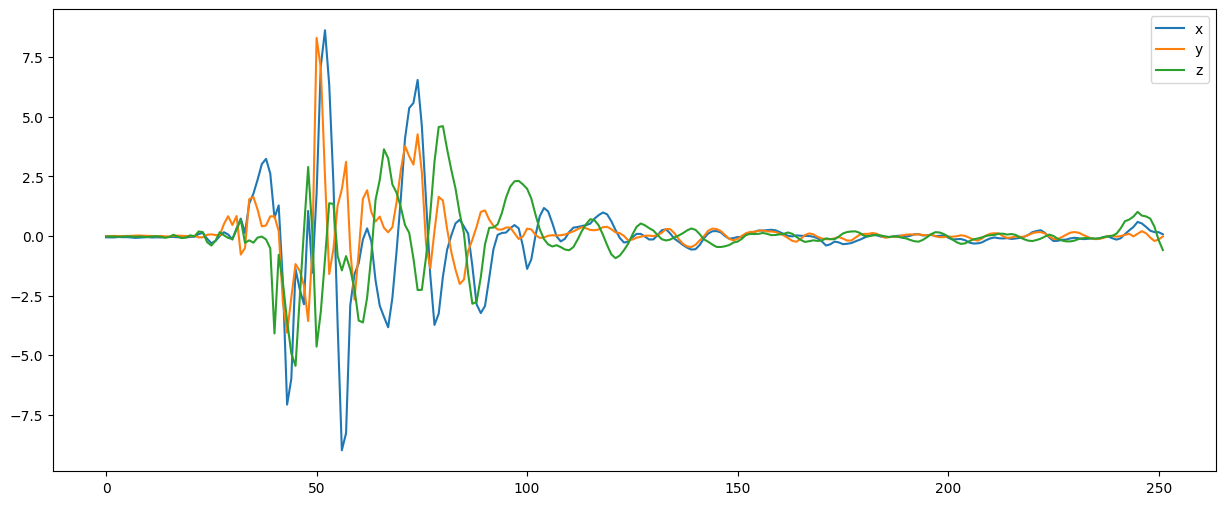

In [15]:
print(len(acc_x))
df[['x', 'y', 'z']].plot(figsize=(15, 6))

<Axes: >

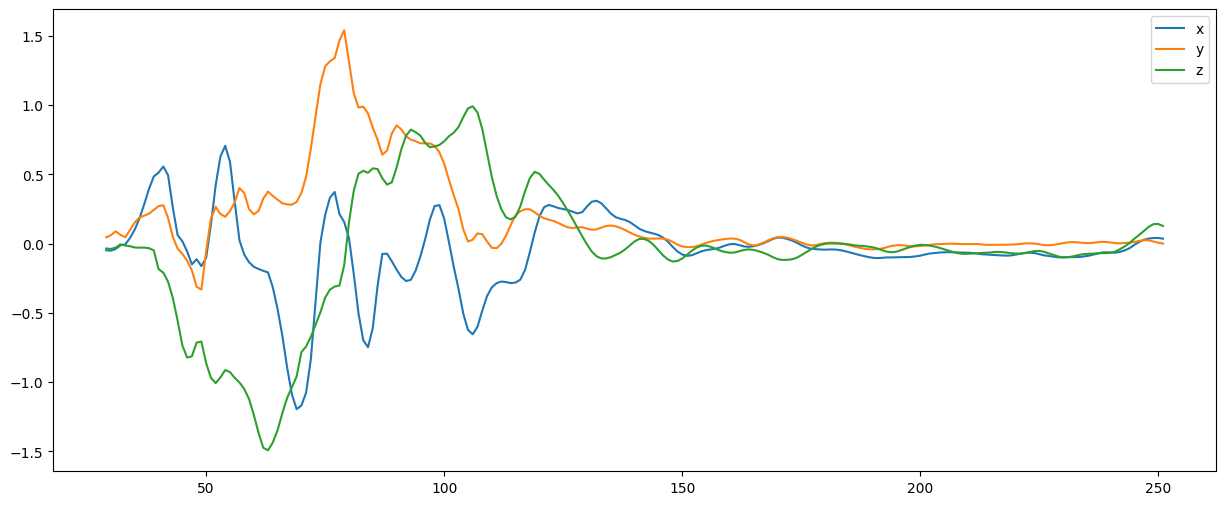

In [16]:
df[['x', 'y', 'z']].rolling(30).mean().plot(figsize=(15, 6))

# ラベルデータの紐付け

In [19]:
label_dict = {
   "a":0,
   "b":1
}

In [20]:
df_dataset = df_acc

In [21]:
df_dataset.shape

(97, 47)

In [22]:
df_dataset.head()

,t-Mean-1,t-Mean-2,t-Mean-3,t-STD-1,t-STD-2,t-STD-3,t-Mad-1,t-Mad-2,t-Mad-3,t-Max-1,...,f-Skewness-3,f-Kurtosis-1,f-Kurtosis-2,f-Kurtosis-3,f-Mean-mag,f-STD-mag,f-Mad-mag,f-Max-mag,f-Min-mag,label
0,0.100422,0.263606,0.064730,1.181117,1.222547,2.358796,0.271592,0.450348,0.426257,4.101208,...,1.710535,5.225460,4.215277,1.945107,0.209824,0.464186,0.067238,3.543999,0.011012,0
0,0.035608,0.235226,-0.139226,1.246105,0.930627,1.872195,0.022775,0.024390,0.013316,4.429158,...,2.522417,4.041020,2.325358,6.629588,0.187157,0.368525,0.074097,2.599206,0.001296,0
0,0.052881,0.206769,-0.028081,1.518757,1.274982,2.190368,0.333389,0.168727,0.595712,4.232324,...,1.351212,1.304608,2.649981,0.283652,0.219362,0.470423,0.075033,3.659322,0.005194,0
0,0.010110,0.311667,-0.102918,1.991136,1.221238,2.698063,0.014328,0.033969,0.026464,6.249111,...,2.005637,4.368322,2.964703,4.001748,0.254928,0.570156,0.112132,4.340308,0.005770,0
0,-0.043469,0.203999,-0.067906,1.499456,1.208048,2.040282,0.368278,0.409625,1.082821,3.847503,...,2.180150,1.557452,0.711356,4.096864,0.208332,0.467620,0.065297,3.937902,0.014207,0


In [23]:
df_dataset.label.unique()

array([0, 1])

# 前処理&特徴量抽出

## データセグメンテーション

In [24]:
# acc_x = df_dataset.x.values
# acc_y = df_dataset.y.values
# acc_z = df_dataset.z.values
# label = df_dataset.label.values

In [25]:
window_size = 180
sliding_size = 90

sliding_acc_x  = sliding_window(acc_x, window_size, sliding_size)
sliding_acc_y  = sliding_window(acc_y, window_size, sliding_size)
sliding_acc_z  = sliding_window(acc_z, window_size, sliding_size)
sliding_label  = sliding_window(label, window_size, sliding_size)
N = len(sliding_acc_x)

## 特徴量抽出

In [26]:
feature_names = time_xyz_feature_names + time_mag_feature_names + frequency_xyz_feature_names + frequency_mag_feature_names 

In [27]:
all_features_acc = np.asarray([generate_all_features_xyz(sliding_acc_x[i], sliding_acc_y[i], sliding_acc_z[i], 100.0)  for i in range(N)])

In [28]:
test_labels = []
for labels in sliding_label:
    test_labels.append(collections.Counter(labels).most_common()[0][0])

In [29]:
df_feature_acc = pd.DataFrame(data=all_features_acc, columns=feature_names)
df_feature_acc['label'] = test_labels

In [30]:
df_feature_acc

,t-Mean-1,t-Mean-2,t-Mean-3,t-STD-1,t-STD-2,t-STD-3,t-Mad-1,t-Mad-2,t-Mad-3,t-Max-1,...,f-Skewness-3,f-Kurtosis-1,f-Kurtosis-2,f-Kurtosis-3,f-Mean-mag,f-STD-mag,f-Mad-mag,f-Max-mag,f-Min-mag,label
0,-0.054896,0.229929,-0.050981,1.956148,1.149279,1.356422,0.419169,0.278608,0.405736,7.124135,...,2.009397,3.832267,0.415931,4.196836,0.210724,0.4138,0.095055,3.26063,0.004897,1


# 機械学習

In [31]:
def generate_cm(df, index, columns, index_name="True Label", columns_name="Estimated Label", figure_size=(7, 5), fontsize=15,  font="Times New Roman", bottom=None, top=None, right=None, left=None):
    cm2 = pd.DataFrame(df, index=index, columns=columns)
    cm3 = cm2.astype('float').div(cm2.sum(axis=1), axis="index")
    cm3_object = pd.DataFrame(cm3.values, index=index, columns=columns, dtype=str)
    
    for i in range(cm3_object.shape[0]):
        for j in range(cm3_object.shape[1]):
            cm3_object.iat[i, j] = "{0:.1f}".format(cm3.iat[i, j]) + "\n" + "(" + str(cm2.iat[i, j]) + ")"
    
    cm3.index.name = "True label"
    cm3.columns.name = "Estimated label"
    sns.set()
    sns.set('talk', 'whitegrid', 'dark', font_scale=1)

    plt.figure()
    plt.rcParams["font.size"] = fontsize
    plt.rcParams['font.family'] = font
    plt.figure(figsize=figure_size)
    plt.xlabel('Predict')
    plt.ylabel('Actual')

    plt.tight_layout()

    sns.heatmap(cm3, annot=cm3_object.values, fmt="", linewidth=2, cmap="gray_r", linecolor="black", vmax=1, vmin=0)


In [32]:
classifiers = [
               ("RF", RandomForestClassifier(random_state=0)),
               # ("ANN", MLPClassifier()),
               # ("LR", LogisticRegression()),
               # ("DT", DecisionTreeClassifier()),
               # ("LR", LogisticRegression()),
               # ("NB", GaussianNB()),
               # ("SVM", SVC()),
               # ("KNN", KNeighborsClassifier())
               ]

In [33]:
X = df_feature_acc[df_feature_acc.columns.values[:-1]].values
Y = df_feature_acc.label.values
labels = np.unique(Y)

In [34]:
# 1. df_acc から特徴量(X)とラベル(y)を切り出す
# 'label'列以外をすべて特徴量(X)にする
X = df_acc.drop(columns=['label'])

# 'label'列を正解ラベル(y)にする
y = df_acc['label']

# 2. 形状を確認（これで (1, 46) ではなく、もっと大きな数になるはずです）
print(f"Xの形状: {X.shape}")
print("ラベルごとのデータ数:")
print(y.value_counts())

# 3. この後に交差検証のコードを実行してください
# 例: 
# from sklearn.model_selection import StratifiedKFold, cross_val_predict
# cv = StratifiedKFold(n_splits=5)
# y_pred = cross_val_predict(model, X, y, cv=cv)

Xの形状: (97, 46)
ラベルごとのデータ数:
label
1    55
0    42
Name: count, dtype: int64


In [35]:
# 1. 結合した df_acc から、特徴量(X)とラベル(Y)を切り出し直す
# ここで大文字の Y を使っている場合は Y = ... としてください
X = df_acc.drop(columns=['label'])
Y = df_acc['label']

# 2. 数が一致しているか確認（どちらも 97 になっている必要があります）
print(f"Xのサンプル数: {len(X)}")
print(f"Yのサンプル数: {len(Y)}")

# 3. この後に cross_val_predict を実行する
# y_pred = cross_val_predict(pipeline, X, Y, cv=cv, ...)

Xのサンプル数: 97
Yのサンプル数: 97


In [36]:
print(X.shape)
print(len(Y))
name, clf = classifiers[0]
scaler = StandardScaler()
#pca = PCA(n_components=0.95)
pipeline = make_pipeline(scaler, clf)

#cv = LeaveOneGroupOut()
cv = StratifiedKFold(5)
y_pred = cross_val_predict(pipeline, X, Y,
                            cv=cv,
                            n_jobs=1, verbose=1)

(97, 46)
97


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.7s finished


In [37]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# 1. データの数と中身を念のため確認
print(f"正解データ(y)の数: {len(y)}")
print(f"予測データ(y_pred)の数: {len(y_pred)}")
print(f"正解データに含まれるラベル: {np.unique(y)}")
print(f"予測データに含まれるラベル: {np.unique(y_pred)}")

# 2. ラベル [0, 1] を明示的に指定して混同行列を作成
# これにより、0 がなくても 2x2 の行列が作られます
labels = [0, 1]
cm = confusion_matrix(y, y_pred, labels=labels)

# 3. 見やすくするためにDataFrame化
# indexとcolumnsに名前を付ける
label_names = ["me(0)", "other(1)"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\n--- 修正後の混同行列 ---")
print(cm_df)

正解データ(y)の数: 97
予測データ(y_pred)の数: 97
正解データに含まれるラベル: [0 1]
予測データに含まれるラベル: [0 1]

--- 修正後の混同行列 ---
    0   1
0  35   7
1  11  44


In [38]:
cr_dict = classification_report(Y, y_pred, output_dict=True)
print(classification_report(Y, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.83      0.80        42
           1       0.86      0.80      0.83        55

    accuracy                           0.81        97
   macro avg       0.81      0.82      0.81        97
weighted avg       0.82      0.81      0.82        97



In [39]:
cm_df

,0,1
0,35,7
1,11,44


<Figure size 640x480 with 0 Axes>

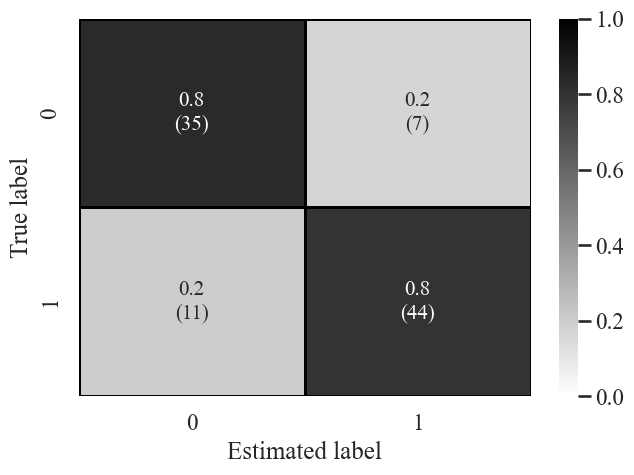

In [40]:
generate_cm(cm_df, index=labels, columns=labels)